<a href="https://colab.research.google.com/github/shahbaz11-arch/NNDDE/blob/main/Problem_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Discovered Network Weights ---
w0: -0.000000
w1: 0.880101
w2: -0.000000

--- Solution Evaluation (11 Test Points) ---
x     | y_approx     | y_exact (sin x) | Relative Error 
-------------------------------------------------------
0.000 | 0.000000     | 0.000000        | 0.0000e+00     
0.100 | 0.099833     | 0.099833        | 3.9896e-14     
0.200 | 0.198669     | 0.198669        | 2.2213e-14     
0.300 | 0.295520     | 0.295520        | 1.5027e-14     
0.400 | 0.389418     | 0.389418        | 1.0406e-14     
0.500 | 0.479426     | 0.479426        | 8.5682e-15     
0.600 | 0.564642     | 0.564642        | 7.4717e-15     
0.700 | 0.644218     | 0.644218        | 6.8935e-15     
0.800 | 0.717356     | 0.717356        | 5.7263e-15     
0.900 | 0.783327     | 0.783327        | 5.8110e-15     
1.000 | 0.841471     | 0.841471        | 1.1874e-15     

--- Error Summary ---
Maximum Absolute Error: 4.5519e-15
Maximum Relative Error: 3.9896e-14


<>:141: SyntaxWarning: invalid escape sequence '\s'
<>:141: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_311/934535619.py:141: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x_eval.numpy(), y_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ($\sin x$)')


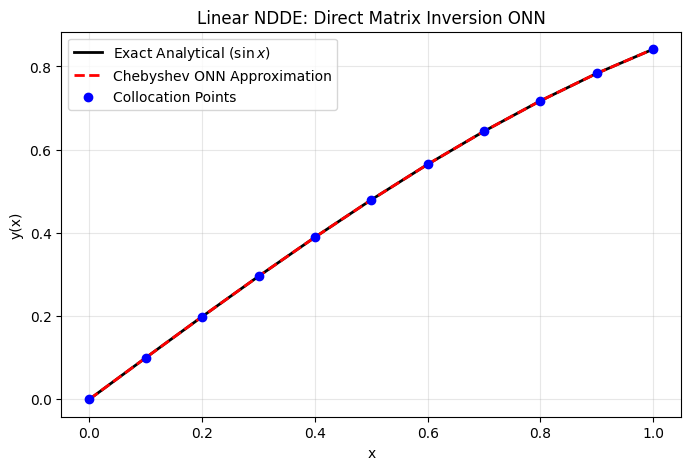

In [9]:
#Problem--2(Chebyshev) (Verified)
import torch
import matplotlib.pyplot as plt

# ==========================================
# 1. Chebyshev Basis Implementation
# ==========================================
def get_chebyshev_basis(x, n_polys):
    """
    Generates Chebyshev polynomials T_n(x) and T'_n(x)
    using recurrence relations for n = 0 to n_polys-1.
    """
    if x.dim() == 0:
        x = x.unsqueeze(0)

    num_points = len(x)
    T = torch.zeros(num_points, n_polys, dtype=torch.float64)
    T_d = torch.zeros(num_points, n_polys, dtype=torch.float64)

    # Base Case: n=0 -> T_0 = 1, T'_0 = 0
    T[:, 0] = 1.0

    if n_polys > 1:
        # Base Case: n=1 -> T_1 = x, T'_1 = 1
        T[:, 1] = x
        T_d[:, 1] = 1.0

    # Recurrence Loop for n >= 2
    for n in range(2, n_polys):
        T[:, n] = 2 * x * T[:, n-1] - T[:, n-2]
        T_d[:, n] = 2 * T[:, n-1] + 2 * x * T_d[:, n-1] - T_d[:, n-2]

    return T, T_d

# ==========================================
# 2. Problem Setup (Linear NDDE)
# ==========================================
N_POLYS = 12
points_colloc = torch.linspace(0,1,11,  dtype=torch.float64)

# Initialize Square System (4 equations, 4 unknowns)
A = torch.zeros(12, N_POLYS, dtype=torch.float64)
b = torch.zeros(12, 1, dtype=torch.float64)

# --- Row 0: Initial Condition y(0) = sin(0) = 0 ---
T_0, _ = get_chebyshev_basis(torch.tensor([0.0], dtype=torch.float64), N_POLYS)
A[0, :] = T_0
b[0, 0] = 0.0

# --- Rows 1-3: ODE Constraints at Collocation Points ---
for i, x_val in enumerate(points_colloc):
    x = torch.tensor([x_val], dtype=torch.float64)

    # 1. Compute delayed/transformed inputs
    delay_1 = torch.exp(-x / 2.0)
    delay_2 = torch.sqrt(x) * torch.exp(-x)

    # 2. Evaluate basis at current, delayed, and transformed arguments
    T_x, Td_x = get_chebyshev_basis(x, N_POLYS)
    _, Td_delay1 = get_chebyshev_basis(delay_1, N_POLYS)
    T_delay2, _ = get_chebyshev_basis(delay_2, N_POLYS)

    # 3. Construct LHS (Coefficients for w_n)
    # y'(x) + sqrt(x)*y'(e^{-x/2}) - y(sqrt(x)*e^{-x}) + y(x)
    coeffs = Td_x + torch.sqrt(x) * (Td_delay1 - T_delay2 + T_x)
    A[i+1, :] = coeffs

    # 4. Construct RHS
    # cos(x) + sqrt(x)*cos(e^{-x/2}) - sin(sqrt(x)*e^{-x}) + sin(x)
    rhs = torch.cos(x) + torch.sqrt(x) * ( torch.cos(delay_1) - torch.sin(delay_2) + torch.sin(x))
    b[i+1, 0] = rhs

# ==========================================
# 3. Solve for Weights (Direct Matrix Inversion)
# ==========================================
# Since the NDDE is linear, we find exact analytical weights using torch.linalg.solve
weights = torch.linalg.solve(A, b)

print("--- Discovered Network Weights ---")
print(f"w0: {weights[0].item():.6f}")
print(f"w1: {weights[1].item():.6f}")
print(f"w2: {weights[2].item():.6f}")
#print(f"w3: {weights[3].item():.6f}")

# ==========================================
# 4. Evaluate Solution and Relative Error
# ==========================================
print("\n--- Solution Evaluation (11 Test Points) ---")
print(f"{'x':<5} | {'y_approx':<12} | {'y_exact (sin x)':<15} | {'Relative Error':<15}")
print("-" * 55)

x_eval = torch.linspace(0, 1, 11, dtype=torch.float64)
T_eval, _ = get_chebyshev_basis(x_eval, N_POLYS)

# Calculate approximate and exact solutions
y_approx = (T_eval @ weights).flatten()
y_exact = torch.sin(x_eval)

# Compute relative error (handle x=0 separately to avoid division by zero)
rel_errors = torch.zeros_like(x_eval)
for i in range(len(x_eval)):
    if x_eval[i] == 0:
        rel_errors[i] = torch.abs(y_approx[i] - y_exact[i]) # Absolute error for exactly 0
    else:
        rel_errors[i] = torch.abs(y_approx[i] - y_exact[i]) / torch.abs(y_exact[i])

for i in range(len(x_eval)):
    x_val = x_eval[i].item()
    approx_val = y_approx[i].item()
    exact_val = y_exact[i].item()
    error_val = rel_errors[i].item()

    print(f"{x_val:<5.3f} | {approx_val:<12.6f} | {exact_val:<15.6f} | {error_val:<15.4e}")


# ==========================================
# Calculate and Print Maximum Errors
# ==========================================

# 1. Calculate Maximum Absolute Error
abs_errors = torch.abs(y_approx - y_exact)
max_abs_err = torch.max(abs_errors).item()

# 2. Calculate Maximum Relative Error (safely handling division by zero)
rel_errors = torch.zeros_like(x_eval)
for i in range(len(x_eval)):
    if y_exact[i] == 0.0:
        rel_errors[i] = abs_errors[i]  # Fallback to absolute error if exact is 0
    else:
        rel_errors[i] = abs_errors[i] / torch.abs(y_exact[i])

max_rel_err = torch.max(rel_errors).item()

# 3. Print Results
print("\n--- Error Summary ---")
print(f"Maximum Absolute Error: {max_abs_err:.4e}")
print(f"Maximum Relative Error: {max_rel_err:.4e}")

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(x_eval.numpy(), y_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ($\sin x$)')
plt.plot(x_eval.numpy(), y_approx.numpy(), 'r--', linewidth=2, label='Chebyshev ONN Approximation')
plt.scatter(points_colloc.numpy(), (get_chebyshev_basis(points_colloc, N_POLYS)[0] @ weights).flatten().numpy(),
            color='blue', zorder=5, label='Collocation Points')
plt.title("Linear NDDE: Direct Matrix Inversion ONN")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<>:133: SyntaxWarning: invalid escape sequence '\s'
<>:133: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_311/3154256976.py:133: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x_eval.numpy(), y_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ($\sin x$)')


--- Discovered Legendre Network Weights ---
w0: -0.000000
w1: 0.903506
w2: -0.000000

--- Solution Evaluation (10 Test Points) ---
x     | y_approx     | y_exact (sin x) | Relative Error 
-------------------------------------------------------
0.000 | 0.000000     | 0.000000        | 0.0000e+00     
0.100 | 0.099833     | 0.099833        | 3.7950e-14     
0.200 | 0.198669     | 0.198669        | 2.1236e-14     
0.300 | 0.295520     | 0.295520        | 1.4088e-14     
0.400 | 0.389418     | 0.389418        | 1.0264e-14     
0.500 | 0.479426     | 0.479426        | 8.7998e-15     
0.600 | 0.564642     | 0.564642        | 7.6683e-15     
0.700 | 0.644218     | 0.644218        | 6.8935e-15     
0.800 | 0.717356     | 0.717356        | 6.0359e-15     
0.900 | 0.783327     | 0.783327        | 5.8110e-15     
1.000 | 0.841471     | 0.841471        | 1.7152e-15     

--- Error Summary ---
Maximum Absolute Error: 4.5519e-15
Maximum Relative Error: 3.7950e-14


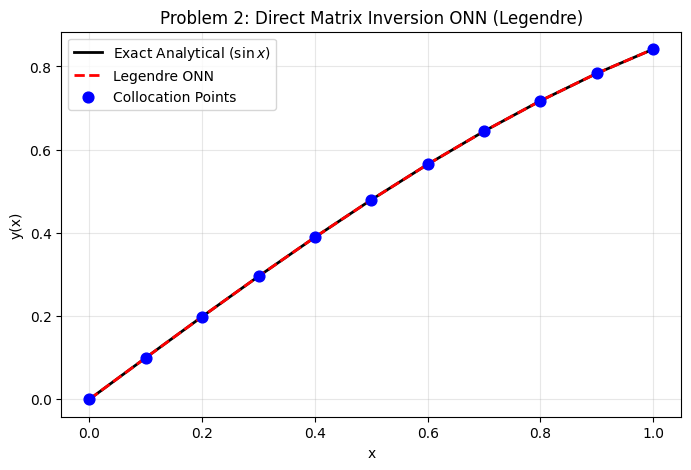

In [10]:
#Problem--2(Legendre)(Verified)
import torch
import matplotlib.pyplot as plt

# ==========================================
# 1. Legendre Basis Implementation
# ==========================================
def get_legendre_basis(x, n_polys):
    """
    Generates Legendre polynomials P_n(x) and their derivatives P'_n(x)
    using Bonnet's recursion formula.
    """
    if x.dim() == 0:
        x = x.unsqueeze(0)

    num_points = len(x)
    P = torch.zeros(num_points, n_polys, dtype=torch.float64)
    P_d = torch.zeros(num_points, n_polys, dtype=torch.float64)

    # Base Case: n=0 -> P_0 = 1, P'_0 = 0
    P[:, 0] = 1.0

    if n_polys > 1:
        # Base Case: n=1 -> P_1 = x, P'_1 = 1
        P[:, 1] = x
        P_d[:, 1] = 1.0

    # Recurrence Loop for n >= 2
    for n in range(2, n_polys):
        P[:, n] = ((2.0 * n - 1.0) * x * P[:, n-1] - (n - 1.0) * P[:, n-2]) / n
        P_d[:, n] = ((2.0 * n - 1.0) * (P[:, n-1] + x * P_d[:, n-1]) - (n - 1.0) * P_d[:, n-2]) / n

    return P, P_d

# ==========================================
# 2. Problem Setup (Problem 2 Linear NDDE)
# ==========================================
N_POLYS = 12
points_colloc = torch.linspace(0,1,11,  dtype=torch.float64)

# Initialize Square System (3 equations, 3 unknowns)
A = torch.zeros(12, N_POLYS, dtype=torch.float64)
b = torch.zeros(12, 1, dtype=torch.float64)

# --- Row 0: Initial Condition y(0) = sin(0) = 0 ---
P_0, _ = get_legendre_basis(torch.tensor([0.0], dtype=torch.float64), N_POLYS)
A[0, :] = P_0
b[0, 0] = 0.0

# --- Rows 1-2: ODE Constraints at Collocation Points ---
for i, x_val in enumerate(points_colloc):
    x = torch.tensor([x_val], dtype=torch.float64)

    # 1. Compute delayed/transformed inputs
    delay_1 = torch.exp(-x / 2.0)
    delay_2 = torch.sqrt(x) * torch.exp(-x)

    # 2. Evaluate basis at current, delayed, and transformed arguments
    P_x, Pd_x = get_legendre_basis(x, N_POLYS)
    _, Pd_delay1 = get_legendre_basis(delay_1, N_POLYS)
    P_delay2, _ = get_legendre_basis(delay_2, N_POLYS)

    # 3. Construct LHS (Coefficients for w_n)
    # y'(x) + sqrt(x) * ( y'(e^{-x/2}) - y(sqrt(x)e^{-x}) + y(x) )
    coeffs = Pd_x + torch.sqrt(x) * (Pd_delay1 - P_delay2 + P_x)
    A[i+1, :] = coeffs

    # 4. Construct RHS
    # cos(x) + sqrt(x) * ( cos(e^{-x/2}) - sin(sqrt(x)e^{-x}) + sin(x) )
    rhs = torch.cos(x) + torch.sqrt(x) * (torch.cos(delay_1) - torch.sin(delay_2) + torch.sin(x))
    b[i+1, 0] = rhs

# ==========================================
# 3. Solve for Weights (Direct Matrix Inversion)
# ==========================================
weights = torch.linalg.solve(A, b)

print("--- Discovered Legendre Network Weights ---")
print(f"w0: {weights[0].item():.6f}")
print(f"w1: {weights[1].item():.6f}")
print(f"w2: {weights[2].item():.6f}")

# ==========================================
# 4. Evaluate Solution and Relative Error
# ==========================================
print("\n--- Solution Evaluation (10 Test Points) ---")
print(f"{'x':<5} | {'y_approx':<12} | {'y_exact (sin x)':<15} | {'Relative Error':<15}")
print("-" * 55)

x_eval = torch.linspace(0, 1, 11, dtype=torch.float64)
P_eval, _ = get_legendre_basis(x_eval, N_POLYS)

y_approx = (P_eval @ weights).flatten()
y_exact = torch.sin(x_eval)

# Compute relative error (handle x=0 safely)
rel_errors = torch.zeros_like(x_eval)
for i in range(len(x_eval)):
    if x_eval[i] == 0:
        rel_errors[i] = torch.abs(y_approx[i] - y_exact[i])
    else:
        rel_errors[i] = torch.abs(y_approx[i] - y_exact[i]) / torch.abs(y_exact[i])

for i in range(len(x_eval)):
    print(f"{x_eval[i].item():<5.3f} | {y_approx[i].item():<12.6f} | {y_exact[i].item():<15.6f} | {rel_errors[i].item():<15.4e}")

# ==========================================
# Calculate and Print Maximum Errors
# ==========================================

# 1. Calculate Maximum Absolute Error
abs_errors = torch.abs(y_approx - y_exact)
max_abs_err = torch.max(abs_errors).item()

# 2. Calculate Maximum Relative Error (safely handling division by zero)
rel_errors = torch.zeros_like(x_eval)
for i in range(len(x_eval)):
    if y_exact[i] == 0.0:
        rel_errors[i] = abs_errors[i]  # Fallback to absolute error if exact is 0
    else:
        rel_errors[i] = abs_errors[i] / torch.abs(y_exact[i])

max_rel_err = torch.max(rel_errors).item()

# 3. Print Results
print("\n--- Error Summary ---")
print(f"Maximum Absolute Error: {max_abs_err:.4e}")
print(f"Maximum Relative Error: {max_rel_err:.4e}")


# Visualization
plt.figure(figsize=(8, 5))
plt.plot(x_eval.numpy(), y_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ($\sin x$)')
plt.plot(x_eval.numpy(), y_approx.numpy(), 'r--', linewidth=2, label='Legendre ONN ')
plt.scatter(points_colloc.numpy(), (get_legendre_basis(points_colloc, N_POLYS)[0] @ weights).flatten().numpy(),
            color='blue', zorder=5, s=60, label='Collocation Points')
plt.title("Problem 2: Direct Matrix Inversion ONN (Legendre)")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<>:144: SyntaxWarning: invalid escape sequence '\s'
<>:144: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_311/2967339622.py:144: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x_eval.numpy(), y_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ($\sin x$)')


--- Discovered Network Weights ---
w0: -0.000013
w1: 0.606563
w2: -0.000061

--- Solution Evaluation (11 Test Points) ---
x     | y_approx     | y_exact (sin x) | Relative Error 
-------------------------------------------------------
0.000 | -0.000000    | 0.000000        | 2.7105e-20     
0.100 | 0.099833     | 0.099833        | 3.7394e-14     
0.200 | 0.198669     | 0.198669        | 2.0397e-14     
0.300 | 0.295520     | 0.295520        | 1.3337e-14     
0.400 | 0.389418     | 0.389418        | 9.5508e-15     
0.500 | 0.479426     | 0.479426        | 7.8735e-15     
0.600 | 0.564642     | 0.564642        | 6.8818e-15     
0.700 | 0.644218     | 0.644218        | 6.2041e-15     
0.800 | 0.717356     | 0.717356        | 5.2620e-15     
0.900 | 0.783327     | 0.783327        | 4.8189e-15     
1.000 | 0.841471     | 0.841471        | 1.3194e-15     

--- Error Summary ---
Maximum Absolute Error: 4.0523e-15
Maximum Relative Error: 3.7394e-14


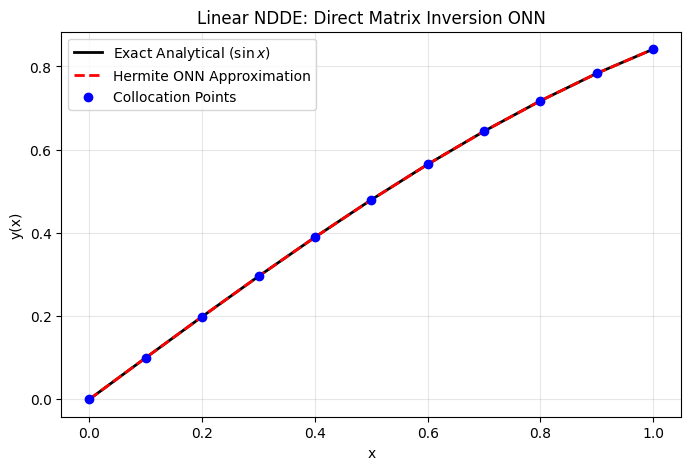

In [11]:
#Problem--2(Hermite)(Verified)
import torch
import matplotlib.pyplot as plt

# ==========================================
# 1. Hermite Basis Implementation
# ==========================================
def get_Hermite_basis(x, n_polys):
    """
    Generates Hermite polynomials T_n(x) and T'_n(x)
    using recurrence relations for n = 0 to n_polys-1.
    """
    if x.dim() == 0:
        x = x.unsqueeze(0)

    num_points = len(x)
    T = torch.zeros(num_points, n_polys, dtype=torch.float64)
    T_d = torch.zeros(num_points, n_polys, dtype=torch.float64)

    # Base Case: n=0 -> T_0 = 1, T'_0 = 0
    T[:, 0] = 1.0

    if n_polys > 1:
        # Base Case: n=1 -> T_1 = x, T'_1 = 1
        T[:, 1] = x
        T_d[:, 1] = 1.0

    # Recurrence Loop for n >= 2
    for n in range(2, n_polys):
      T[:, n] = x * T[:, n-1] - (n - 1.0) * T[:, n-2]

        # He'_n(x) = n * He_{n-1}(x)
      T_d[:, n] = float(n) * T[:, n-1]


    return T, T_d

# ==========================================
# 2. Problem Setup (Linear NDDE)
# ==========================================
N_POLYS = 12
points_colloc = torch.linspace(0,1,11,   dtype=torch.float64)

# Initialize Square System (4 equations, 4 unknowns)
A = torch.zeros(12, N_POLYS, dtype=torch.float64)
b = torch.zeros(12, 1, dtype=torch.float64)

# --- Row 0: Initial Condition y(0) = sin(0) = 0 ---
T_0, _ = get_Hermite_basis(torch.tensor([0.0], dtype=torch.float64), N_POLYS)
A[0, :] = T_0
b[0, 0] = 0.0

# --- Rows 1-3: ODE Constraints at Collocation Points ---
for i, x_val in enumerate(points_colloc):
    x = torch.tensor([x_val], dtype=torch.float64)

    # 1. Compute delayed/transformed inputs
    delay_1 = torch.exp(-x / 2.0)
    delay_2 = torch.sqrt(x) * torch.exp(-x)

    # 2. Evaluate basis at current, delayed, and transformed arguments
    T_x, Td_x = get_Hermite_basis(x, N_POLYS)
    _, Td_delay1 = get_Hermite_basis(delay_1, N_POLYS)
    T_delay2, _ = get_Hermite_basis(delay_2, N_POLYS)

    # 3. Construct LHS (Coefficients for w_n)
    # y'(x) + sqrt(x)*y'(e^{-x/2}) - y(sqrt(x)*e^{-x}) + y(x)
    coeffs = Td_x + torch.sqrt(x) * (Td_delay1 - T_delay2 + T_x)
    A[i+1, :] = coeffs

    # 4. Construct RHS
    # cos(x) + sqrt(x)*cos(e^{-x/2}) - sin(sqrt(x)*e^{-x}) + sin(x)
    rhs = torch.cos(x) + torch.sqrt(x) * ( torch.cos(delay_1) - torch.sin(delay_2) + torch.sin(x))
    b[i+1, 0] = rhs

# ==========================================
# 3. Solve for Weights (Direct Matrix Inversion)
# ==========================================
# Since the NDDE is linear, we find exact analytical weights using torch.linalg.solve
weights = torch.linalg.solve(A, b)

print("--- Discovered Network Weights ---")
print(f"w0: {weights[0].item():.6f}")
print(f"w1: {weights[1].item():.6f}")
print(f"w2: {weights[2].item():.6f}")
#print(f"w3: {weights[3].item():.6f}")

# ==========================================
# 4. Evaluate Solution and Relative Error
# ==========================================
print("\n--- Solution Evaluation (11 Test Points) ---")
print(f"{'x':<5} | {'y_approx':<12} | {'y_exact (sin x)':<15} | {'Relative Error':<15}")
print("-" * 55)

x_eval = torch.linspace(0, 1, 11, dtype=torch.float64)
T_eval, _ = get_Hermite_basis(x_eval, N_POLYS)

# Calculate approximate and exact solutions
y_approx = (T_eval @ weights).flatten()
y_exact = torch.sin(x_eval)

# Compute relative error (handle x=0 separately to avoid division by zero)
rel_errors = torch.zeros_like(x_eval)
for i in range(len(x_eval)):
    if x_eval[i] == 0:
        rel_errors[i] = torch.abs(y_approx[i] - y_exact[i]) # Absolute error for exactly 0
    else:
        rel_errors[i] = torch.abs(y_approx[i] - y_exact[i]) / torch.abs(y_exact[i])

for i in range(len(x_eval)):
    x_val = x_eval[i].item()
    approx_val = y_approx[i].item()
    exact_val = y_exact[i].item()
    error_val = rel_errors[i].item()

    print(f"{x_val:<5.3f} | {approx_val:<12.6f} | {exact_val:<15.6f} | {error_val:<15.4e}")

# ==========================================
# Calculate and Print Maximum Errors
# ==========================================

# 1. Calculate Maximum Absolute Error
abs_errors = torch.abs(y_approx - y_exact)
max_abs_err = torch.max(abs_errors).item()

# 2. Calculate Maximum Relative Error (safely handling division by zero)
rel_errors = torch.zeros_like(x_eval)
for i in range(len(x_eval)):
    if y_exact[i] == 0.0:
        rel_errors[i] = abs_errors[i]  # Fallback to absolute error if exact is 0
    else:
        rel_errors[i] = abs_errors[i] / torch.abs(y_exact[i])

max_rel_err = torch.max(rel_errors).item()

# 3. Print Results
print("\n--- Error Summary ---")
print(f"Maximum Absolute Error: {max_abs_err:.4e}")
print(f"Maximum Relative Error: {max_rel_err:.4e}")


# Visualization
plt.figure(figsize=(8, 5))
plt.plot(x_eval.numpy(), y_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ($\sin x$)')
plt.plot(x_eval.numpy(), y_approx.numpy(), 'r--', linewidth=2, label='Hermite ONN Approximation')
plt.scatter(points_colloc.numpy(), (get_Hermite_basis(points_colloc, N_POLYS)[0] @ weights).flatten().numpy(),
            color='blue', zorder=5, label='Collocation Points')
plt.title("Linear NDDE: Direct Matrix Inversion ONN")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()